In [4]:
from google.colab import files

uploaded = files.upload()


Saving messy_ecommerce_sales_data.csv to messy_ecommerce_sales_data (2).csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("messy_ecommerce_sales_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (103, 11)


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (103, 11)

Column Names:
['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product', ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']

Data Types:
ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

First 5 Rows:


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [7]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

Duplicate Rows:
1


In [8]:
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows after cleaning: 0
New dataset shape: (102, 11)


In [9]:
print(df.dtypes)

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object


In [10]:
print(df["Quantity"].unique())
print(df["Price"].unique())
print(df["Total"].unique())

['3' '2' '1' '5' nan '4' '-2' '-5' '4a']
['38' 'abd' '389.05' '233.92' '552.51' '122.06' '978.63' '587.68' '600.29'
 '168.34' 'four hundred' '865.77' '752.13' '411.81' '413.13' '796.84' nan
 '10000' '247.82' '438.19' '300$' '523.01' '556.93' '615.91' '765.69'
 '836.8' '336.02' '898.69' '736.71' '616.63' '266.7' '343.24' '591.53'
 '446.19' '696.71' '-100' '531.06' '681.38' '588.98' '546.04' '645.26'
 '826.77' '849.07' '860.99' '705.42' '596.15' '660.98' '896.38' '206.19'
 '457.16' '233.11' '278.9' '789.64' '40.95' '275.1' '933.58' '163.16'
 '242.52' '209.32' '155.76' '235.26' '587.64' '443.13' '569.38' '593.93'
 '141.49' '582.13' '741.63' '688.68' '942.76' '351.89' '187.48' '111.36'
 '530.52' '69.48' '472.14' '868.67' '418.38' '266.48' '538.35' '101.19'
 '730.92' '365.34' '882.96' '504.05' '814.68' '920.37' '881.02' '203.63'
 '522.02' '944.54' '817.46' '160.16' '497.01' '372.28']
[   114.           nan    389.05    1169.6      552.51     366.18
   2938.4      600.29     841.7     1731.5

In [11]:
# Convert Quantity and Price to numeric
# Invalid values will become NaN

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(
    df["Price"].astype(str).str.replace("$", "", regex=False),
    errors="coerce"
)

print("Quantity invalid/missing values:")
print(df["Quantity"].isnull().sum())

print("\nPrice invalid/missing values:")
print(df["Price"].isnull().sum())

print("\nData types after conversion:")
print(df[["Quantity", "Price"]].dtypes)

Quantity invalid/missing values:
6

Price invalid/missing values:
8

Data types after conversion:
Quantity    float64
Price       float64
dtype: object


In [12]:
# Fill missing Quantity with median
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

# Fill missing Price with median
df["Price"] = df["Price"].fillna(df["Price"].median())

print("Missing Quantity:", df["Quantity"].isnull().sum())
print("Missing Price:", df["Price"].isnull().sum())

Missing Quantity: 0
Missing Price: 0


In [13]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']


In [14]:
# Fill missing Category with the most common category
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])

# Recalculate Total using Quantity × Price
df["Total"] = df["Quantity"] * df["Price"]

print("Missing Category:", df["Category"].isnull().sum())
print("Missing Total:", df["Total"].isnull().sum())

Missing Category: 0
Missing Total: 0


In [15]:
print("Invalid Quantity rows:")
display(df[df["Quantity"] < 0])

print("\nInvalid Price rows:")
display(df[df["Price"] < 0])

Invalid Quantity rows:


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2/12/2025,Blender,electronic,-2.0,10000.00,Cash on Delivery,Processing,-20000.00
34,134,Customer_134,ORD-16585,10/4/2025,T-shirt,Clothing,-5.0,591.53,PayPal,Shipped,-2957.65



Invalid Price rows:


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
37,137,Customer_137,ORD-91254,2/23/2025,Vacuum,Home,3.0,-100.0,Cash on Delivery,Delivered,-300.0


In [16]:
# Remove rows with negative Quantity or Price
df = df[(df["Quantity"] >= 0) & (df["Price"] >= 0)]

print("Dataset shape after removing invalid values:", df.shape)

print("\nNegative Quantity values:", (df["Quantity"] < 0).sum())
print("Negative Price values:", (df["Price"] < 0).sum())

Dataset shape after removing invalid values: (99, 11)

Negative Quantity values: 0
Negative Price values: 0


In [17]:
# Calculate Q1, Q3 and IQR for Price

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 289.45
Q3: 701.065
IQR: 411.61500000000007
Lower limit: -327.97250000000014
Upper limit: 1318.4875000000002


In [18]:
# Display Price outliers

price_outliers = df[
    (df["Price"] < lower_limit) |
    (df["Price"] > upper_limit)
]

print("Number of Price outliers:", len(price_outliers))

display(price_outliers[["ID", "Product", "Price", "Quantity", "Total"]])

Number of Price outliers: 0


,ID,Product,Price,Quantity,Total


In [19]:
# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Order_Date data type:")
print(df["Order_Date"].dtype)

print("\nMissing dates:")
print(df["Order_Date"].isnull().sum())

Order_Date data type:
datetime64[ns]

Missing dates:
2


In [20]:
# Create a clean independent copy
df = df.copy()

# Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Remove rows where Order_Date is missing
df = df.dropna(subset=["Order_Date"])

print("Missing dates:", df["Order_Date"].isnull().sum())
print("Dataset shape:", df.shape)

Missing dates: 0
Dataset shape: (97, 11)


In [21]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

Duplicate rows: 2

Data types:
ID                         int64
Customer_Name             object
Order_ID                  object
Order_Date        datetime64[ns]
Product                   object
Category                  object
Quantity                 float64
Price                    float64
Payment_Method            object
Status                    object
Total                    float64
dtype: object


In [22]:
# Remove duplicate rows
df = df.drop_duplicates().copy()

print("Duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

Duplicate rows: 0
Final dataset shape: (95, 11)


In [23]:
print("Missing values:")
print(df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nFinal shape:", df.shape)

Missing values:
0
Duplicate rows: 0

Final shape: (95, 11)


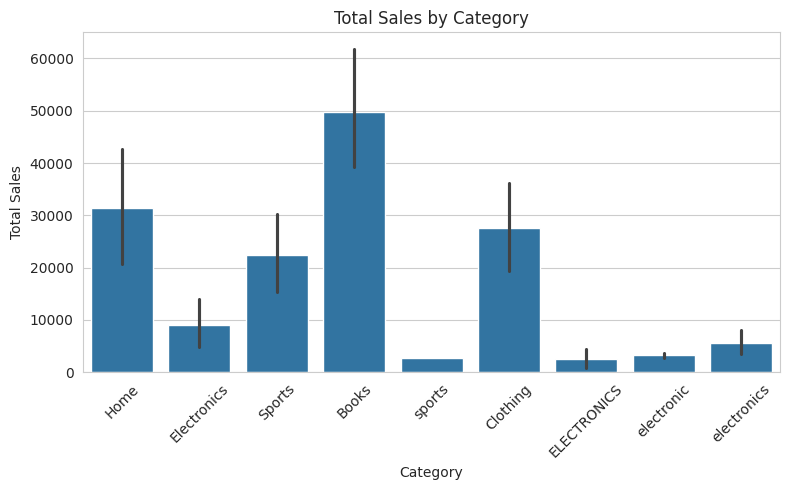

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Category",
    y="Total",
    estimator="sum"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Standardize category names
df["Category"] = df["Category"].str.strip().str.title()

print(df["Category"].value_counts())

Category
Books          30
Home           19
Sports         17
Electronics    15
Clothing       12
Electronic      2
Name: count, dtype: int64


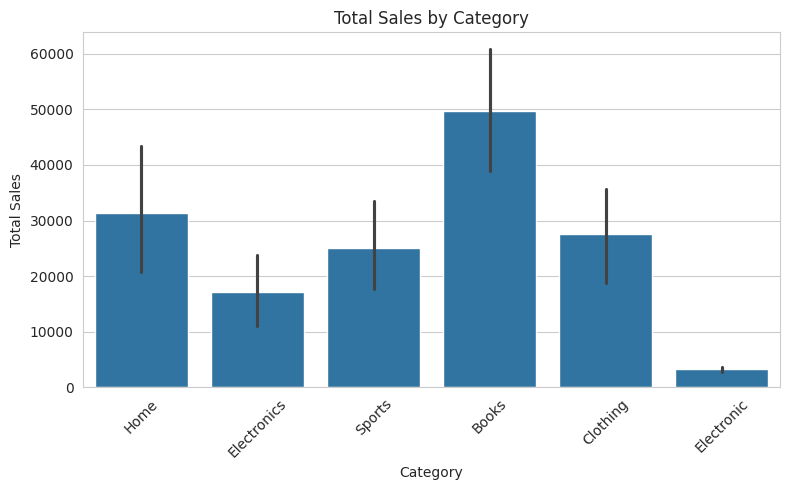

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Category",
    y="Total",
    estimator="sum"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df["Category"] = df["Category"].replace({
    "Electronic": "Electronics"
})

print(df["Category"].value_counts())

Category
Books          30
Home           19
Electronics    17
Sports         17
Clothing       12
Name: count, dtype: int64


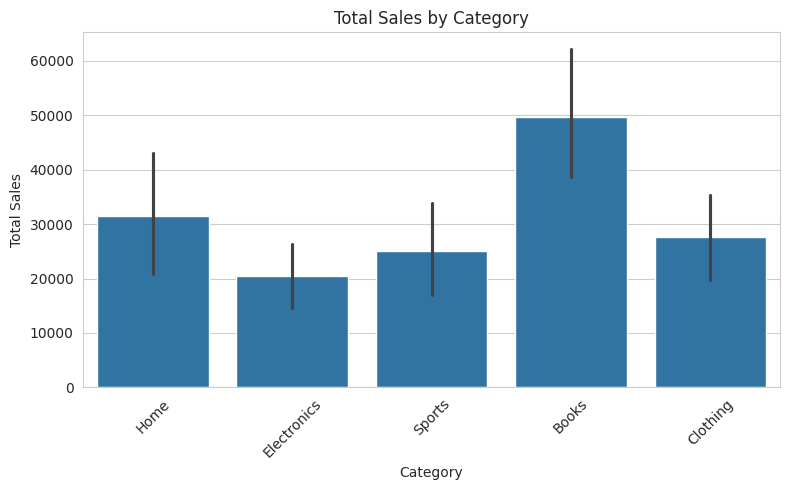

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Category",
    y="Total",
    estimator="sum"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

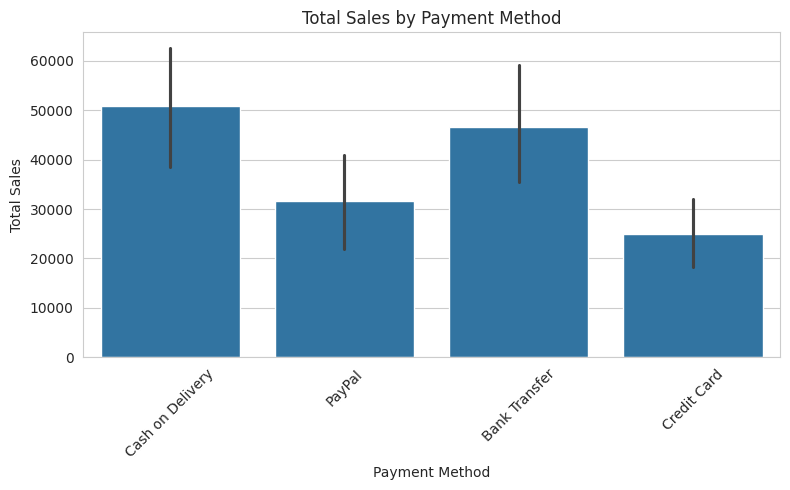

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Payment_Method",
    y="Total",
    estimator="sum"
)

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

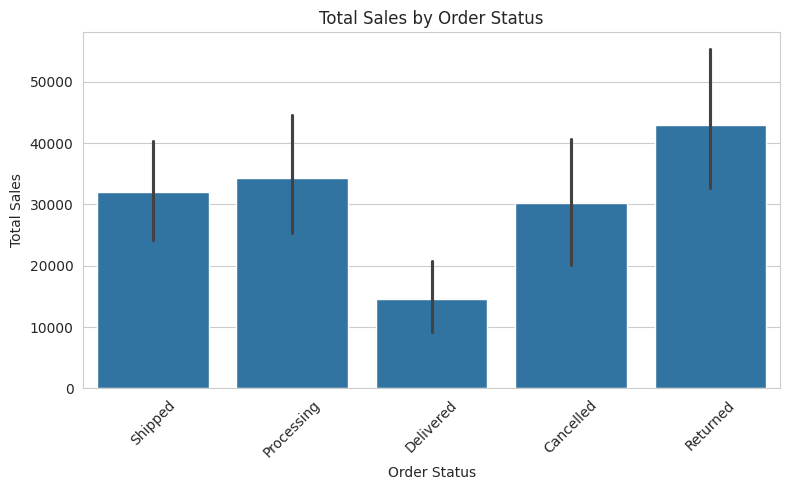

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Status",
    y="Total",
    estimator="sum"
)

plt.title("Total Sales by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

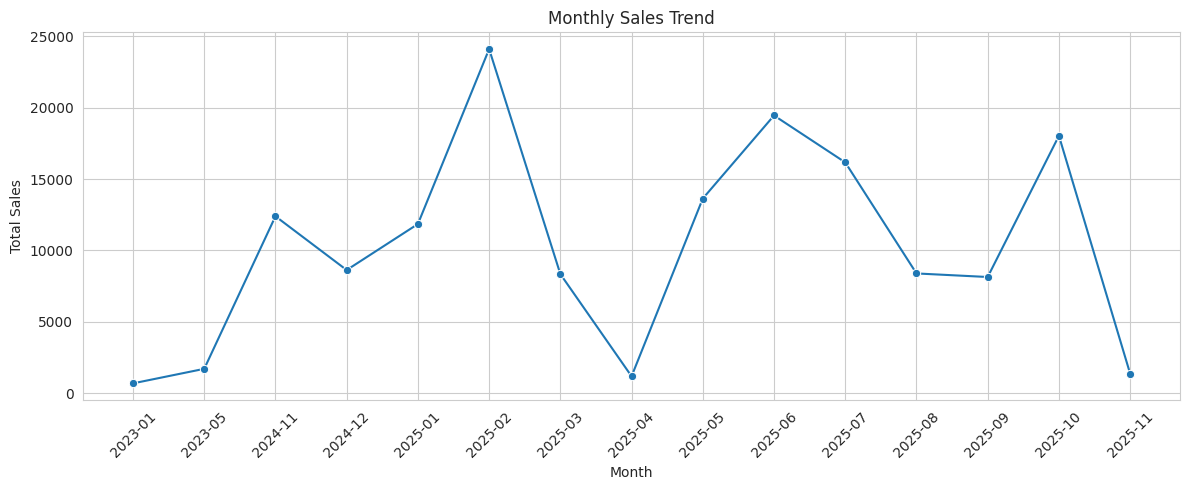

In [31]:
# Create Month column
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

# Calculate monthly sales
monthly_sales = df.groupby("Month")["Total"].sum().reset_index()

# Plot monthly sales
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Total",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

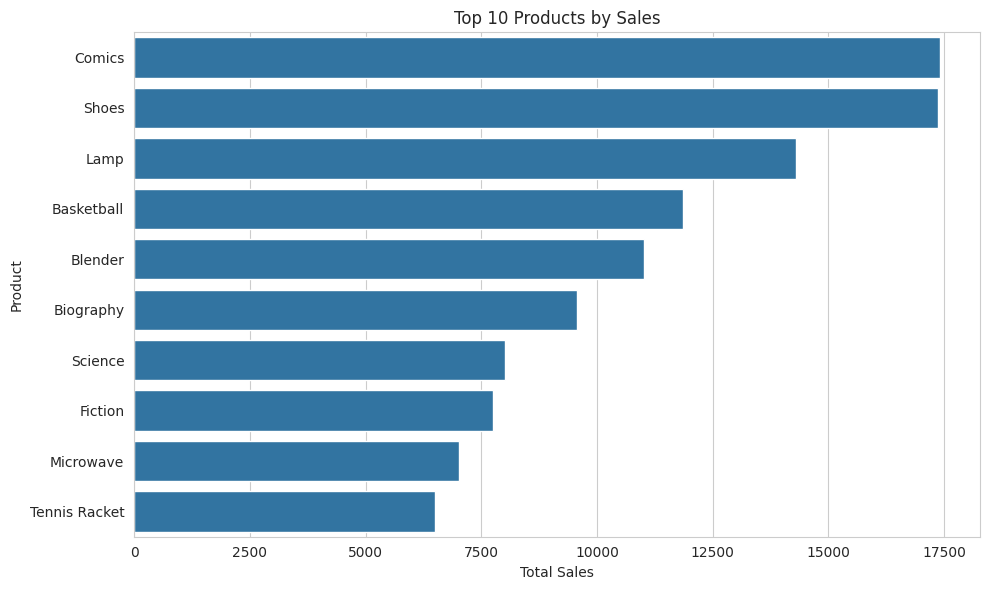

In [32]:
# Calculate top 10 products by total sales
top_products = (
    df.groupby("Product")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x="Total",
    y="Product"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

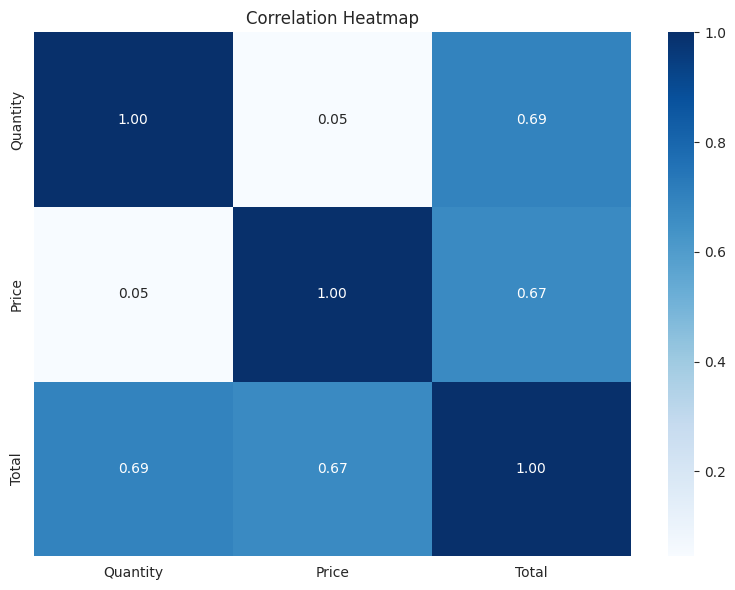

In [33]:
plt.figure(figsize=(8, 6))

numeric_df = df[["Quantity", "Price", "Total"]]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [34]:
df.to_csv("cleaned_ecommerce_sales_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [37]:
df.to_csv("cleaned_ecommerce_sales_data.csv", index=False)

In [38]:
from google.colab import files

files.download("cleaned_ecommerce_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# ============================================
# E-COMMERCE SALES ANALYTICS DASHBOARD
# ============================================

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. LOAD CLEANED DATASET
df = pd.read_csv("cleaned_ecommerce_sales_data.csv")

# 2. FIX DATA TYPES
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

# 3. STANDARDIZE CATEGORY
df["Category"] = df["Category"].str.strip().str.title()
df["Category"] = df["Category"].replace({
    "Electronic": "Electronics"
})

# ============================================
# KPI CALCULATIONS
# ============================================

total_sales = df["Total"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
average_order_value = df["Total"].mean()

# ============================================
# MONTHLY SALES
# ============================================

monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Total"]
    .sum()
    .reset_index()
)

monthly_sales["Month"] = monthly_sales["Order_Date"].astype(str)

# ============================================
# SALES BY CATEGORY
# ============================================

category_sales = (
    df.groupby("Category")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# ============================================
# PAYMENT METHOD
# ============================================

payment_sales = (
    df.groupby("Payment_Method")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# ============================================
# ORDER STATUS
# ============================================

status_sales = (
    df.groupby("Status")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# ============================================
# TOP 10 PRODUCTS
# ============================================

top_products = (
    df.groupby("Product")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .reset_index()
)

# ============================================
# CORRELATION
# ============================================

correlation = df[["Quantity", "Price", "Total"]].corr()

# ============================================
# CREATE DASHBOARD
# ============================================

fig = make_subplots(
    rows=3,
    cols=4,

    specs=[
        [
            {"type": "indicator"},
            {"type": "indicator"},
            {"type": "indicator"},
            {"type": "indicator"}
        ],

        [
            {"type": "xy", "colspan": 2},
            None,
            {"type": "xy", "colspan": 2},
            None
        ],

        [
            {"type": "domain"},
            {"type": "domain"},
            {"type": "xy"},
            {"type": "xy"}
        ]
    ],

    vertical_spacing=0.12,

    subplot_titles=(
        "",
        "",
        "",
        "",
        "Monthly Sales Trend",
        "Sales by Category",
        "Sales by Payment Method",
        "Sales by Order Status",
        "Top 10 Products by Sales",
        "Correlation Heatmap"
    )
)

# ============================================
# KPI 1
# ============================================

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        number={
            "prefix": "₹ ",
            "valueformat": ",.0f"
        },
        title={"text": "TOTAL SALES"}
    ),
    row=1,
    col=1
)

# ============================================
# KPI 2
# ============================================

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_orders,
        title={"text": "TOTAL ORDERS"}
    ),
    row=1,
    col=2
)

# ============================================
# KPI 3
# ============================================

fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_quantity,
        title={"text": "TOTAL QUANTITY"}
    ),
    row=1,
    col=3
)

# ============================================
# KPI 4
# ============================================

fig.add_trace(
    go.Indicator(
        mode="number",
        value=average_order_value,
        number={
            "prefix": "₹ ",
            "valueformat": ",.2f"
        },
        title={"text": "AVERAGE ORDER VALUE"}
    ),
    row=1,
    col=4
)

# ============================================
# MONTHLY SALES TREND
# ============================================

fig.add_trace(
    go.Scatter(
        x=monthly_sales["Month"],
        y=monthly_sales["Total"],
        mode="lines+markers",
        name="Monthly Sales",
        line={"width": 3},
        hovertemplate=
        "Month: %{x}<br>Sales: ₹%{y:,.2f}<extra></extra>"
    ),
    row=2,
    col=1
)

# ============================================
# SALES BY CATEGORY
# ============================================

fig.add_trace(
    go.Bar(
        x=category_sales["Category"],
        y=category_sales["Total"],
        name="Category Sales",
        hovertemplate=
        "Category: %{x}<br>Sales: ₹%{y:,.2f}<extra></extra>"
    ),
    row=2,
    col=3
)

# ============================================
# PAYMENT METHOD
# ============================================

fig.add_trace(
    go.Pie(
        labels=payment_sales["Payment_Method"],
        values=payment_sales["Total"],
        hole=0.45,
        name="Payment Method"
    ),
    row=3,
    col=1
)

# ============================================
# ORDER STATUS
# ============================================

fig.add_trace(
    go.Pie(
        labels=status_sales["Status"],
        values=status_sales["Total"],
        hole=0.45,
        name="Order Status"
    ),
    row=3,
    col=2
)

# ============================================
# TOP 10 PRODUCTS
# ============================================

fig.add_trace(
    go.Bar(
        x=top_products["Total"],
        y=top_products["Product"],
        orientation="h",
        name="Top Products",
        hovertemplate=
        "Product: %{y}<br>Sales: ₹%{x:,.2f}<extra></extra>"
    ),
    row=3,
    col=3
)

# ============================================
# CORRELATION HEATMAP
# ============================================

fig.add_trace(
    go.Heatmap(
        z=correlation.values,
        x=correlation.columns,
        y=correlation.columns,
        text=correlation.round(2).values,
        texttemplate="%{text}",
        colorscale="Blues",
        zmin=-1,
        zmax=1
    ),
    row=3,
    col=4
)

# ============================================
# DASHBOARD FORMATTING
# ============================================

fig.update_layout(
    title={
        "text": "E-Commerce Sales Analytics Dashboard",
        "x": 0.5,
        "xanchor": "center"
    },
    height=1100,
    width=1500,
    template="plotly_white",
    showlegend=False,
    font=dict(
        family="Arial",
        size=12
    )
)

fig.update_xaxes(title_text="Month", row=2, col=1)
fig.update_yaxes(title_text="Total Sales", row=2, col=1)

fig.update_xaxes(title_text="Category", row=2, col=3)
fig.update_yaxes(title_text="Total Sales", row=2, col=3)

fig.update_xaxes(title_text="Total Sales", row=3, col=3)
fig.update_yaxes(title_text="Product", row=3, col=3)

# SHOW DASHBOARD
fig.show()